<a href="https://colab.research.google.com/github/BhavanaMudadla/retail-purchase-pattern-analysis/blob/main/Clothes_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [ ]:
url = 'https://drive.google.com/uc?id=1OipnRZqCKDa2FimhXns-aZLpeO-1m59b'
df = pd.read_csv(url)

print("Shape:", df.shape)
print(df.dtypes)
df.head()

Shape: (3900, 19)
Customer ID                   int64
Age                           int64
Gender                       object
Item Purchased               object
Category                     object
Purchase Amount (USD)         int64
Location                     object
Size                         object
Color                        object
Season                       object
Review Rating               float64
Subscription Status          object
Payment Method               object
Shipping Type                object
Discount Applied             object
Promo Code Used              object
Previous Purchases            int64
Preferred Payment Method     object
Frequency of Purchases       object
dtype: object


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [ ]:
age_bins   = [12, 25, 40, 55, 71]
age_labels = ['Young Adult', 'Middle Aged', 'Senior', 'Elder']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

# Spending Level
spend_bins   = [0, 40, 70, 101]
spend_labels = ['Low', 'Medium', 'High']
df['SpendingLevel'] = pd.cut(df['Purchase Amount (USD)'], bins=spend_bins, labels=spend_labels)

# Customer Type based on purchase history
cust_bins   = [0, 10, 30, 51]
cust_labels = ['New', 'Regular', 'Loyal']
df['CustomerType'] = pd.cut(df['Previous Purchases'], bins=cust_bins, labels=cust_labels)

# Verify no NaNs from binning
print("NaNs after binning:")
print(df[['AgeGroup', 'SpendingLevel', 'CustomerType']].isna().sum())

NaNs after binning:
AgeGroup         0
SpendingLevel    0
CustomerType     0
dtype: int64


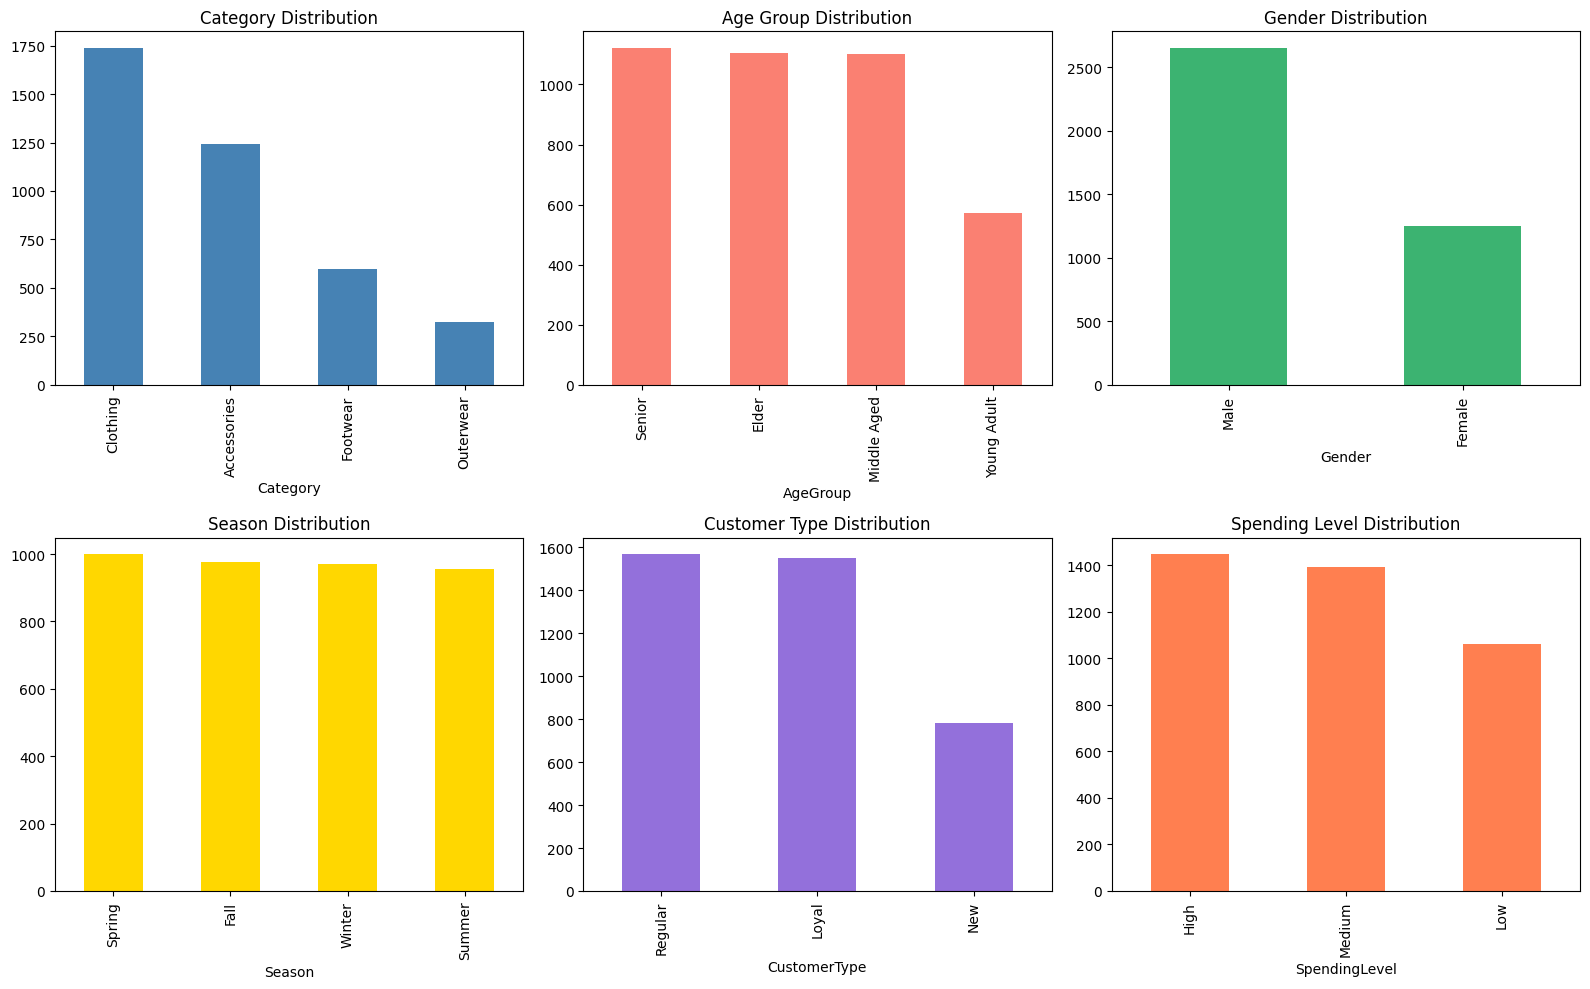

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

df['Category'].value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Category Distribution')

df['AgeGroup'].value_counts().plot(kind='bar', ax=axes[0,1], color='salmon')
axes[0,1].set_title('Age Group Distribution')

df['Gender'].value_counts().plot(kind='bar', ax=axes[0,2], color='mediumseagreen')
axes[0,2].set_title('Gender Distribution')

df['Season'].value_counts().plot(kind='bar', ax=axes[1,0], color='gold')
axes[1,0].set_title('Season Distribution')

df['CustomerType'].value_counts().plot(kind='bar', ax=axes[1,1], color='mediumpurple')
axes[1,1].set_title('Customer Type Distribution')

df['SpendingLevel'].value_counts().plot(kind='bar', ax=axes[1,2], color='coral')
axes[1,2].set_title('Spending Level Distribution')

plt.tight_layout()
plt.show()

Overall category split:
 Category
Clothing       0.445385
Accessories    0.317949
Footwear       0.153590
Outerwear      0.083077
Name: proportion, dtype: float64

Top category preference by Age Group:
AgeGroup
Young Adult       Clothing
Middle Aged    Accessories
Senior            Footwear
Elder          Accessories
dtype: object

Top category preference by Season:
Season
Fall      Accessories
Spring       Footwear
Summer       Footwear
Winter       Clothing
dtype: object

Top category preference by Spending Level:
SpendingLevel
Low         Outerwear
Medium    Accessories
High         Clothing
dtype: object


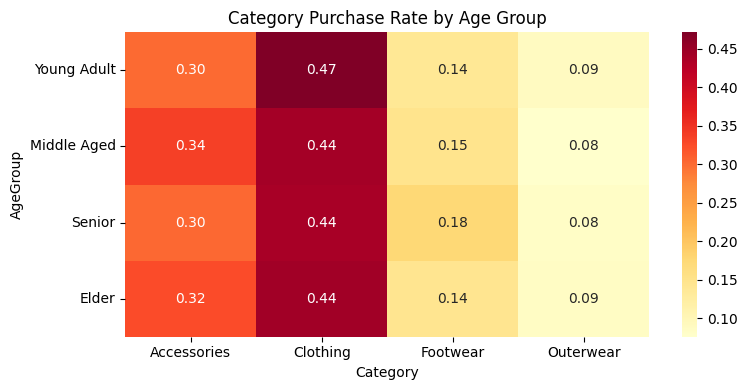

In [ ]:
# Overall category proportions (baseline)
overall = df['Category'].value_counts(normalize=True)
print("Overall category split:\n", overall)

# Which category each Age Group over-indexes on
ct_age = pd.crosstab(df['AgeGroup'], df['Category'], normalize='index')
diff_age = ct_age - overall
print("\nTop category preference by Age Group:")
print(diff_age.idxmax(axis=1))

# Season
ct_season = pd.crosstab(df['Season'], df['Category'], normalize='index')
diff_season = ct_season - overall
print("\nTop category preference by Season:")
print(diff_season.idxmax(axis=1))

# Spending Level
ct_spending = pd.crosstab(df['SpendingLevel'], df['Category'], normalize='index')
diff_spending = ct_spending - overall
print("\nTop category preference by Spending Level:")
print(diff_spending.idxmax(axis=1))

# Heatmap of age vs category
plt.figure(figsize=(8, 4))
sns.heatmap(ct_age, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Category Purchase Rate by Age Group')
plt.tight_layout()
plt.show()

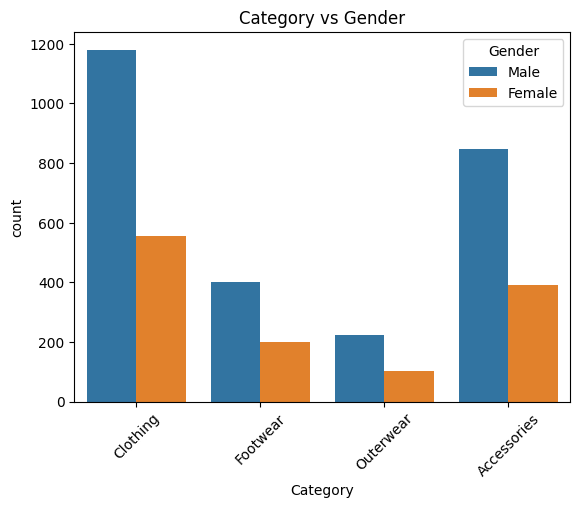

In [ ]:
sns.countplot(x='Category', hue='Gender', data=df)
plt.xticks(rotation=45)
plt.title("Category vs Gender")
plt.show()


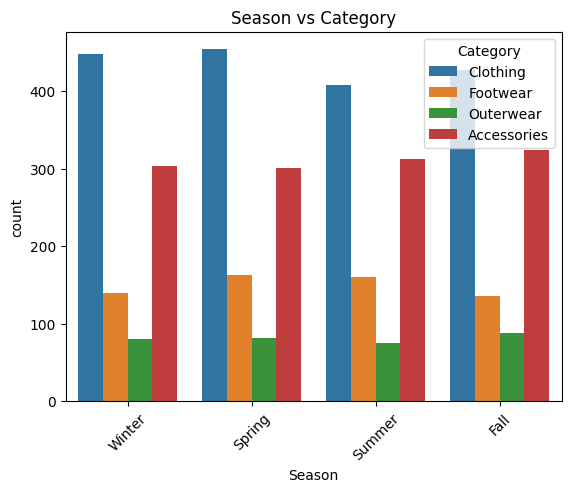

In [ ]:
sns.countplot(x='Season', hue='Category', data=df)
plt.xticks(rotation=45)
plt.title("Season vs Category")
plt.show()

In [ ]:
# Age Group
age_bins = [12, 20, 28, 40, 50]
age_labels = ['Teenager', 'Young Adult', 'Middle aged', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

# Spending Level
spend_bins = [0, 30, 70, 120]
spend_labels = ['Low', 'Medium', 'High']
df['SpendingLevel'] = pd.cut(df['Purchase Amount (USD)'], bins=spend_bins, labels=spend_labels)

# Customer Type
cust_bins = [0, 10, 30, 100]
cust_labels = ['New', 'Regular', 'Loyal']
df['CustomerType'] = pd.cut(df['Previous Purchases'], bins=cust_bins, labels=cust_labels)

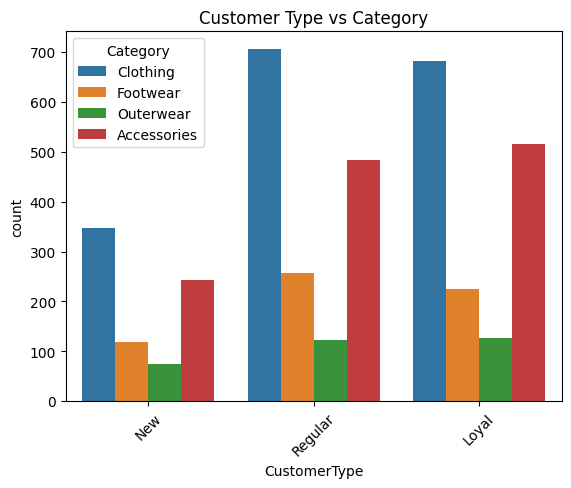

In [ ]:
sns.countplot(x='CustomerType', hue='Category', data=df)
plt.xticks(rotation=45)
plt.title("Customer Type vs Category")
plt.show()

In [ ]:
feature_cols = [
    'AgeGroup', 'Gender', 'SpendingLevel', 'CustomerType',
    'Season', 'Subscription Status',
    # Added useful behavioral features:
    'Discount Applied', 'Promo Code Used', 'Frequency of Purchases'
]

X = df[feature_cols].copy()
y = df['Category'].copy()

# FIX: Use a separate LabelEncoder per column so we can decode later
encoders = {}
for col in X.columns:
    encoders[col] = LabelEncoder()
    X[col] = encoders[col].fit_transform(X[col].astype(str))

label_enc_y = LabelEncoder()
y_encoded = label_enc_y.fit_transform(y)

print("Feature matrix shape:", X.shape)
print("Classes:", label_enc_y.classes_)

Feature matrix shape: (3900, 9)
Classes: ['Accessories' 'Clothing' 'Footwear' 'Outerwear']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 3120 rows | Test: 780 rows


In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       n_jobs=-1, random_state=42)

Test Accuracy: 0.3384615384615385
5-Fold CV Accuracy: 0.348 ± 0.014

Classification Report:
              precision    recall  f1-score   support

 Accessories       0.33      0.29      0.31       248
    Clothing       0.47      0.50      0.48       347
    Footwear       0.15      0.14      0.14       120
   Outerwear       0.01      0.02      0.01        65

    accuracy                           0.34       780
   macro avg       0.24      0.24      0.24       780
weighted avg       0.34      0.34      0.34       780



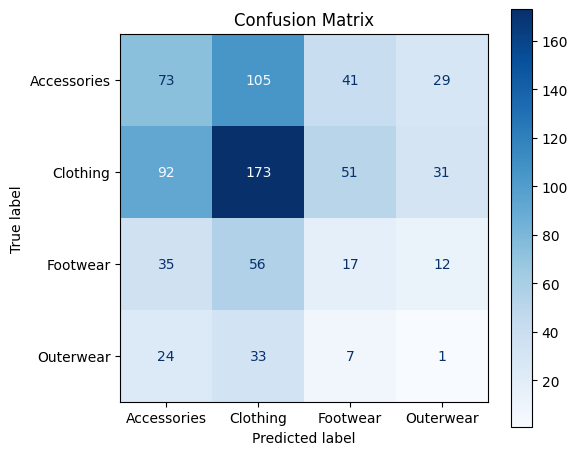

In [ ]:
y_pred = model.predict(X_test)

# FIX: Removed the incorrect "1 - accuracy"
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# Cross-validation for reliable estimate
cv_scores = cross_val_score(model, X, y_encoded, cv=5, scoring='accuracy')
print(f"5-Fold CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Per-class breakdown
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_enc_y.classes_))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=label_enc_y.classes_,
    ax=ax, cmap='Blues'
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

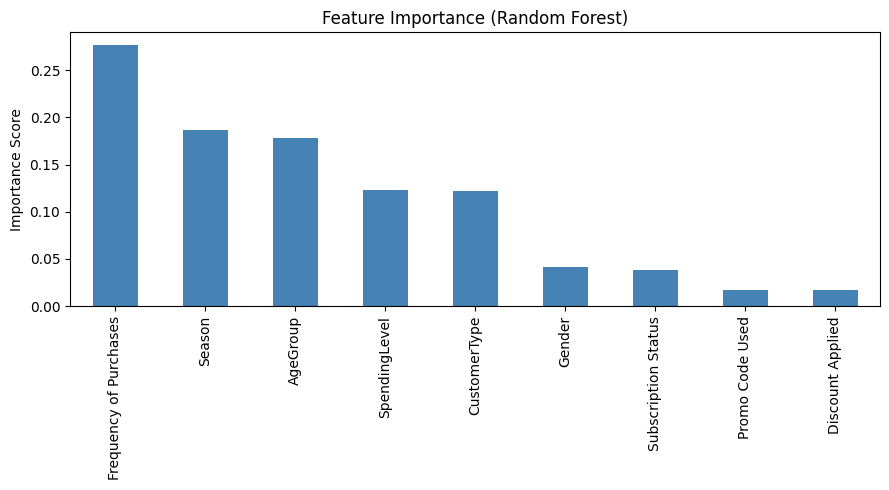

Feature weights:
 Frequency of Purchases    0.276391
Season                    0.186280
AgeGroup                  0.178154
SpendingLevel             0.123168
CustomerType              0.121917
Gender                    0.041344
Subscription Status       0.038699
Promo Code Used           0.017112
Discount Applied          0.016935
dtype: float64


In [ ]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance_sorted = importance.sort_values(ascending=False)

plt.figure(figsize=(9, 5))
importance_sorted.plot(kind='bar', color='steelblue')
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

# Weights for use in recommendation
weights = importance / importance.sum()
print("Feature weights:\n", weights.sort_values(ascending=False))

In [ ]:
def recommend_category(age_group, season, spending):
    """
    Returns the recommended Category for a customer profile
    using weighted cross-tab scores from training data.
    """
    # Guard: handle unseen values gracefully
    age_score     = diff_age.loc[age_group]     if age_group in diff_age.index     else pd.Series(0, index=diff_age.columns)
    season_score  = diff_season.loc[season]     if season in diff_season.index     else pd.Series(0, index=diff_season.columns)
    spend_score   = diff_spending.loc[spending] if spending in diff_spending.index else pd.Series(0, index=diff_spending.columns)

    total_score = (
        age_score    * weights.get('AgeGroup', 0) +
        season_score * weights.get('Season', 0) +
        spend_score  * weights.get('SpendingLevel', 0)
    )
    return total_score.idxmax()

In [ ]:
FREQ_BONUS = {
    'Weekly':          5,
    'Bi-Weekly':       4,
    'Fortnightly':     4,
    'Monthly':         3,
    'Every 3 Months':  2,
    'Quarterly':       2,
    'Annually':        0,
}

def generate_coupon(customer_type, frequency, category):
    """
    Returns a coupon dict with a discount code based on loyalty + frequency.
    """
    base_discounts = {'Loyal': 20, 'Regular': 10, 'New': 5}
    base_codes     = {'Loyal': 'LOYAL20', 'Regular': 'REG10', 'New': 'WELCOME5'}

    discount = base_discounts.get(str(customer_type), 5)
    code     = base_codes.get(str(customer_type), 'SAVE5')

    # Frequency bonus stacks on top
    extra    = FREQ_BONUS.get(str(frequency), 0)
    total    = discount + extra

    return {
        'code':             code,
        'discount_percent': total,
        'category':         category,
        'message':          f"Use code {code} for {total}% off on {category}!"
    }


In [ ]:
def generate_full_offer(age_group, season, spending, customer_type, frequency):
    """
    Given a customer profile, returns a personalised ad + coupon offer.
    """
    category = recommend_category(age_group, season, spending)

    # Tone by age group
    tone_map = {
        'Young Adult':  "✨ Upgrade your style!",
        'Middle Aged':  "👌 Smart and practical picks!",
        'Senior':       "🧓 Comfort comes first!",
        'Elder':        "🌿 Quality you can trust!",
    }
    tone = tone_map.get(str(age_group), "🛍️ Check this out!")

    # Price messaging
    price_map = {
        'Low':    "Budget-friendly deals",
        'Medium': "Great value picks",
        'High':   "Premium collection",
    }
    price = price_map.get(str(spending), "Special offers")

    # Category-specific product description
    product_map = {
        'Clothing':    f"{season}-ready outfits",
        'Accessories': "watches, bags & stylish add-ons",
        'Footwear':    "comfortable and stylish footwear",
        'Outerwear':   f"{season} jackets and hoodies",
    }
    product = product_map.get(category, "top picks")

    ad_text = f"{tone} {price} on {product} tailored for {age_group}s this {season}!"

    coupon  = generate_coupon(customer_type, frequency, category)

    return {
        'ad':      ad_text,
        'coupon':  coupon['message'],
        'full':    f"{ad_text}\n🎟️  {coupon['message']}"
    }

In [ ]:
sample_customers = [
    # (age_group,    season,  spending, customer_type, frequency)
    ('Young Adult',  'Winter', 'High',   'Loyal',   'Weekly'),
    ('Middle Aged',  'Spring', 'Medium', 'Regular', 'Monthly'),
    ('Senior',       'Fall',   'Low',    'New',     'Annually'),
    ('Elder',        'Summer', 'Medium', 'Loyal',   'Every 3 Months'),
]

print("=" * 65)
print("PERSONALISED OFFER DEMO")
print("=" * 65)
for profile in sample_customers:
    offer = generate_full_offer(*profile)
    print(f"\nProfile: {profile}")
    print(offer['full'])
    print("-" * 65)

PERSONALISED OFFER DEMO

Profile: ('Young Adult', 'Winter', 'High', 'Loyal', 'Weekly')
✨ Upgrade your style! Premium collection on Winter-ready outfits tailored for Young Adults this Winter!
🎟️  Use code LOYAL20 for 25% off on Clothing!
-----------------------------------------------------------------

Profile: ('Middle Aged', 'Spring', 'Medium', 'Regular', 'Monthly')
👌 Smart and practical picks! Great value picks on comfortable and stylish footwear tailored for Middle Ageds this Spring!
🎟️  Use code REG10 for 13% off on Footwear!
-----------------------------------------------------------------

Profile: ('Senior', 'Fall', 'Low', 'New', 'Annually')
🧓 Comfort comes first! Budget-friendly deals on Fall jackets and hoodies tailored for Seniors this Fall!
🎟️  Use code WELCOME5 for 5% off on Outerwear!
-----------------------------------------------------------------

Profile: ('Elder', 'Summer', 'Medium', 'Loyal', 'Every 3 Months')
🌿 Quality you can trust! Great value picks on watches, ba

In [ ]:
df['RecommendedCategory'] = df.apply(
    lambda r: recommend_category(r['AgeGroup'], r['Season'], r['SpendingLevel']),
    axis=1
)

df['CouponOffer'] = df.apply(
    lambda r: generate_coupon(
        r['CustomerType'],
        r['Frequency of Purchases'],
        r['RecommendedCategory']
    )['message'],
    axis=1
)

print("\nSample of enriched DataFrame:")
print(df[['AgeGroup', 'Season', 'SpendingLevel', 'CustomerType',
          'Frequency of Purchases', 'RecommendedCategory', 'CouponOffer']].head(10).to_string())


Sample of enriched DataFrame:
      AgeGroup  Season SpendingLevel CustomerType Frequency of Purchases RecommendedCategory                                   CouponOffer
0       Senior  Winter        Medium      Regular            Fortnightly            Footwear       Use code REG10 for 14% off on Footwear!
1  Young Adult  Winter        Medium          New            Fortnightly            Clothing     Use code WELCOME5 for 9% off on Clothing!
2       Senior  Spring          High      Regular                 Weekly            Footwear       Use code REG10 for 15% off on Footwear!
3  Young Adult  Spring          High        Loyal                 Weekly            Clothing     Use code LOYAL20 for 25% off on Clothing!
4       Senior  Spring        Medium        Loyal               Annually            Footwear     Use code LOYAL20 for 20% off on Footwear!
5       Senior  Summer           Low      Regular                 Weekly            Footwear       Use code REG10 for 15% off on Footwe